In [1]:
import sys
import os

# Make sure the project root is on the path so we can import config
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from config.settings import DATA_RAW_DIR, FRED_SERIES

# ── Plotting style ───────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('tab10')
plt.rcParams.update({
    'figure.dpi'    : 120,
    'font.size'     : 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Imports OK')
print(f'Raw data directory: {DATA_RAW_DIR}')
print(f'Series to load: {list(FRED_SERIES.keys())}')

Imports OK
Raw data directory: c:\Yash\GDP_Project\data\raw
Series to load: ['gdp', 'cpi', 'm2', 'fed_funds', 'unrate', 'indpro']


In [2]:
series_dfs = {}   # dict to hold individual DataFrames

for name in FRED_SERIES.keys():
    filepath = os.path.join(DATA_RAW_DIR, f'{name}.csv')
    df = pd.read_csv(filepath, parse_dates=['date'], index_col='date')
    df.columns = [name]        # rename 'value' → series name
    df.index.name = 'date'
    series_dfs[name] = df
    print(f'  Loaded {name:10s} | rows: {len(df):4d} | '
          f'{df.index.min().date()} → {df.index.max().date()}')

print('\n All 6 series loaded.')

  Loaded gdp        | rows:  105 | 2000-01-01 → 2026-01-01
  Loaded cpi        | rows:  316 | 2000-01-01 → 2026-05-01
  Loaded m2         | rows:  316 | 2000-01-01 → 2026-04-01
  Loaded fed_funds  | rows:  317 | 2000-01-01 → 2026-05-01
  Loaded unrate     | rows:  316 | 2000-01-01 → 2026-05-01
  Loaded indpro     | rows:  316 | 2000-01-01 → 2026-04-01

 All 6 series loaded.


In [3]:
print(f"{'Series':<12} {'Rows':>6} {'Freq':>8} {'Start':>12} {'End':>12} {'Dtype':>10}")
print('-' * 65)

for name, df in series_dfs.items():
    # Infer frequency from median time delta between consecutive dates
    deltas = df.index.to_series().diff().dropna()
    median_days = deltas.median().days
    if median_days < 35:
        freq = 'Monthly'
    elif median_days < 100:
        freq = 'Quarterly'
    else:
        freq = 'Annual'

    print(f"{name:<12} {len(df):>6} {freq:>8} "
          f"{str(df.index.min().date()):>12} "
          f"{str(df.index.max().date()):>12} "
          f"{str(df.dtypes[name]):>10}")

Series         Rows     Freq        Start          End      Dtype
-----------------------------------------------------------------
gdp             105 Quarterly   2000-01-01   2026-01-01    float64
cpi             316  Monthly   2000-01-01   2026-05-01    float64
m2              316  Monthly   2000-01-01   2026-04-01    float64
fed_funds       317  Monthly   2000-01-01   2026-05-01    float64
unrate          316  Monthly   2000-01-01   2026-05-01    float64
indpro          316  Monthly   2000-01-01   2026-04-01    float64


**Key insight:** GDP (`gdp`) is **quarterly**, while the 5 sensor series are **monthly**. This frequency mismatch is the core engineering challenge we'll solve in the feature engineering step — we will align everything to quarterly frequency.

In [4]:
for name, df in series_dfs.items():
    print(f'\n── {name.upper()} ─────────────────────────────')
    print(df.describe().round(3).to_string())


── GDP ─────────────────────────────
             gdp
count    105.000
mean   18328.611
std     2890.386
min    13878.147
25%    16326.281
50%    17662.400
75%    20558.879
max    24152.656

── CPI ─────────────────────────────
           cpi
count  316.000
mean   234.709
std     42.608
min    169.300
25%    201.975
50%    231.845
75%    256.033
max    333.979

── M2 ─────────────────────────────
              m2
count    316.000
mean   11922.077
std     5710.954
min     4667.600
25%     6917.225
50%    10555.650
75%    15081.275
max    22804.500

── FED_FUNDS ─────────────────────────────
       fed_funds
count    317.000
mean       2.034
std        2.026
min        0.050
25%        0.150
50%        1.300
75%        3.940
max        6.540

── UNRATE ─────────────────────────────
        unrate
count  316.000
mean     5.623
std      1.936
min      3.400
25%      4.200
50%      5.000
75%      6.200
max     14.800

── INDPRO ─────────────────────────────
        indpro
count  316.000
me

In [5]:
print(f"{'Series':<12} {'Total Rows':>12} {'NaN Count':>10} {'NaN %':>8}")
print('-' * 48)

any_missing = False
for name, df in series_dfs.items():
    nan_count = df.isnull().sum()[name]
    nan_pct   = 100 * nan_count / len(df)
    
    # Emoji flag hata diya gaya hai
    print(f"{name:<12} {len(df):>12} {nan_count:>10} {nan_pct:>7.2f}%")
    
    if nan_count > 0:
        any_missing = True

if not any_missing:
    print('\nNo missing values in any series — clean dataset!')
else:
    print('\nMissing values detected — will handle in feature engineering step.')

Series         Total Rows  NaN Count    NaN %
------------------------------------------------
gdp                   105          0    0.00%
cpi                   316          0    0.00%
m2                    316          0    0.00%
fed_funds             317          0    0.00%
unrate                316          0    0.00%
indpro                316          0    0.00%

No missing values in any series — clean dataset!


In [6]:
from statsmodels.tsa.stattools import adfuller

for name, df in series_dfs.items():
    result = adfuller(df[name].dropna())
    p_value = result[1]
    status = "STATIONARY" if p_value < 0.05 else "NON-STATIONARY"
    print(f"{name:<12} | p-value: {p_value:.4f} | {status}")

gdp          | p-value: 0.9941 | NON-STATIONARY
cpi          | p-value: 0.9983 | NON-STATIONARY
m2           | p-value: 0.9867 | NON-STATIONARY
fed_funds    | p-value: 0.0037 | STATIONARY
unrate       | p-value: 0.0358 | STATIONARY
indpro       | p-value: 0.2535 | NON-STATIONARY


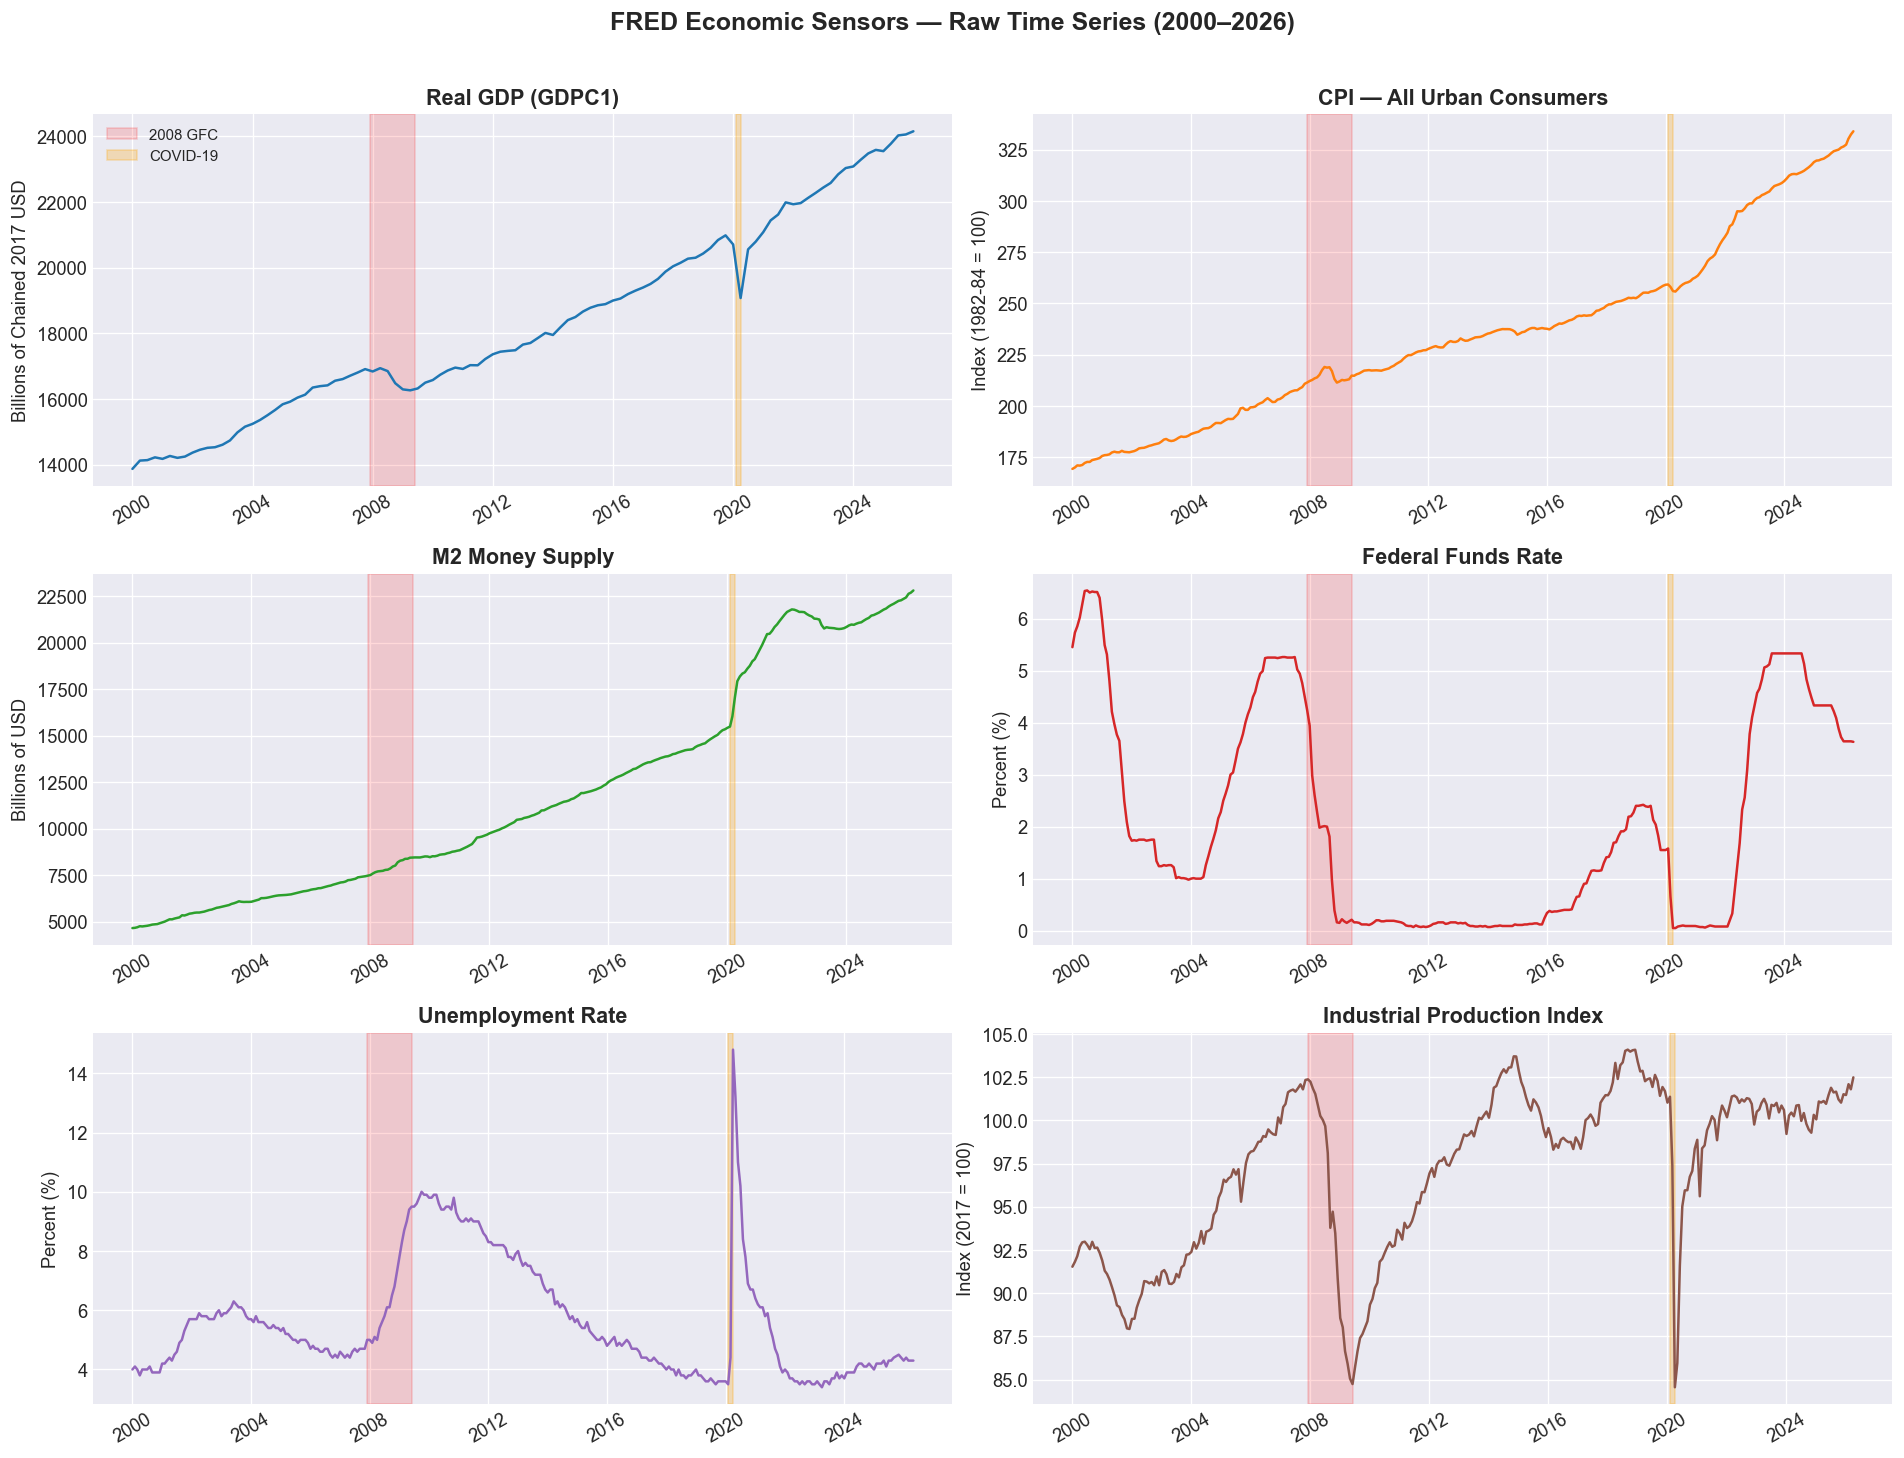

In [7]:
# Labels and units for readable axis titles
SERIES_META = {
    'gdp'      : ('Real GDP (GDPC1)',             'Billions of Chained 2017 USD'),
    'cpi'      : ('CPI — All Urban Consumers',    'Index (1982-84 = 100)'),
    'm2'       : ('M2 Money Supply',              'Billions of USD'),
    'fed_funds' : ('Federal Funds Rate',           'Percent (%)'),
    'unrate'   : ('Unemployment Rate',            'Percent (%)'),
    'indpro'   : ('Industrial Production Index',  'Index (2017 = 100)'),
}

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, df) in enumerate(series_dfs.items()):
    ax = axes[i]
    label, unit = SERIES_META[name]

    ax.plot(df.index, df[name], linewidth=1.5, color=f'C{i}')

    # Shade 2008 GFC and COVID-19 recession periods
    ax.axvspan(pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01'),
               alpha=0.15, color='red', label='2008 GFC')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'),
               alpha=0.25, color='orange', label='COVID-19')

    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(unit)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.tick_params(axis='x', rotation=30)

    if i == 0:   # legend only on first subplot
        ax.legend(fontsize=9, loc='upper left')

plt.suptitle('FRED Economic Sensors — Raw Time Series (2000–2026)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
gdp = series_dfs['gdp'].copy()

# Quarter-over-Quarter growth rate (pct change from previous quarter)
gdp['gdp_growth_qoq'] = gdp['gdp'].pct_change() * 100

# Annualized growth rate (what news media reports: compound quarterly rate × 4)
gdp['gdp_growth_ann'] = ((1 + gdp['gdp'].pct_change()) ** 4 - 1) * 100

print('GDP Growth Rate — Last 8 quarters:')
print(gdp[['gdp', 'gdp_growth_qoq', 'gdp_growth_ann']].tail(8).round(3).to_string())

GDP Growth Rate — Last 8 quarters:
                  gdp  gdp_growth_qoq  gdp_growth_ann
date                                                 
2024-04-01  23286.508           0.885           3.589
2024-07-01  23478.570           0.825           3.340
2024-10-01  23586.542           0.460           1.852
2025-01-01  23548.210          -0.163          -0.648
2025-04-01  23770.976           0.946           3.838
2025-07-01  24026.834           1.076           4.375
2025-10-01  24055.749           0.120           0.482
2026-01-01  24152.656           0.403           1.621


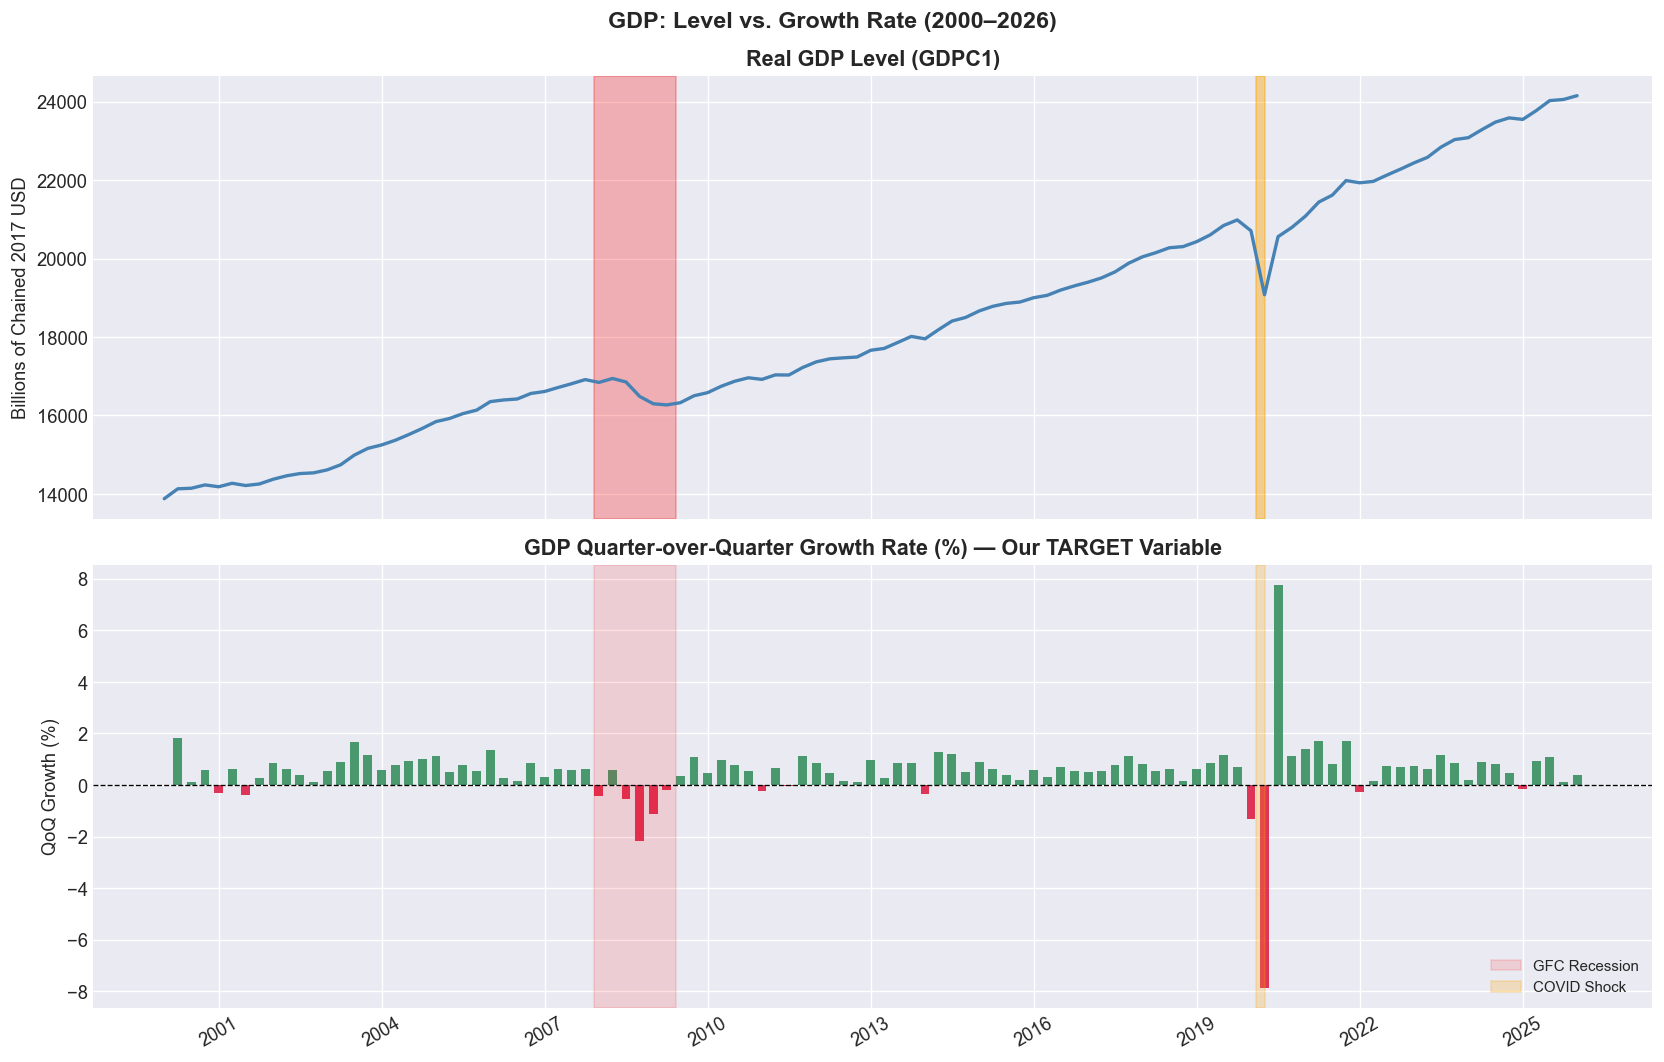

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: GDP Level ────────────────────────────────────────────
ax1.plot(gdp.index, gdp['gdp'], color='steelblue', linewidth=2)
ax1.set_title('Real GDP Level (GDPC1)', fontweight='bold')
ax1.set_ylabel('Billions of Chained 2017 USD')
ax1.axvspan(pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01'),
            alpha=0.15, color='red')
ax1.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'),
            alpha=0.25, color='orange')

# ── Bottom: QoQ Growth Rate ───────────────────────────────────
colors = ['crimson' if v < 0 else 'seagreen'
          for v in gdp['gdp_growth_qoq'].fillna(0)]
ax2.bar(gdp.index, gdp['gdp_growth_qoq'], color=colors,
        width=60, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('GDP Quarter-over-Quarter Growth Rate (%) — Our TARGET Variable',
              fontweight='bold')
ax2.set_ylabel('QoQ Growth (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(3))
ax2.tick_params(axis='x', rotation=30)

# Annotate recession shading
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01'),
               alpha=0.12, color='red', label='GFC Recession')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'),
               alpha=0.22, color='orange', label='COVID Shock')

ax2.legend(fontsize=9, loc='lower right')
plt.suptitle('GDP: Level vs. Growth Rate (2000–2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Resample monthly series to quarterly (last value in each quarter)
monthly_series = ['cpi', 'm2', 'fed_funds', 'unrate', 'indpro']
quarterly_dfs = [series_dfs['gdp']]

for name in monthly_series:
    resampled = series_dfs[name].resample('QS').last()  # Quarter-Start
    quarterly_dfs.append(resampled)

# Merge all into one master DataFrame on the quarterly index
master = pd.concat(quarterly_dfs, axis=1).dropna()

print(f'Master DataFrame shape: {master.shape}')
print(f'Date range: {master.index.min().date()} → {master.index.max().date()}')
print()
print(master.tail(5).round(2).to_string())

Master DataFrame shape: (105, 6)
Date range: 2000-01-01 → 2026-01-01

                 gdp     cpi       m2  fed_funds  unrate  indpro
date                                                            
2025-01-01  23548.21  319.79  21693.7       4.33     4.2  101.04
2025-04-01  23770.98  321.44  21938.8       4.33     4.1  101.48
2025-07-01  24026.83  324.24  22170.3       4.22     4.4  101.67
2025-10-01  24055.75  326.03  22353.5       3.72     4.4  101.52
2026-01-01  24152.66  330.29  22686.4       3.64     4.3  101.81


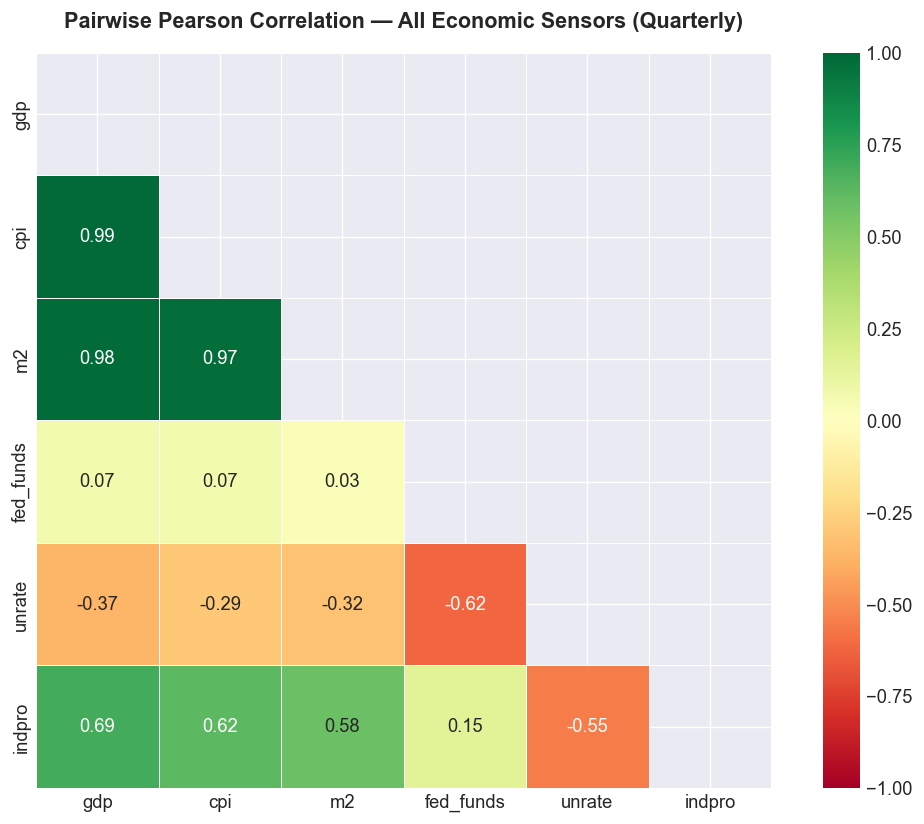


  Note: High correlation between levels (e.g. GDP & M2) is expected
    — both trend upward over time. In Phase 2 we will use GROWTH RATES
    and Z-scores to remove this spurious trend correlation.


In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

corr_matrix = master.corr().round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Pairwise Pearson Correlation — All Economic Sensors (Quarterly)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n  Note: High correlation between levels (e.g. GDP & M2) is expected')
print('    — both trend upward over time. In Phase 2 we will use GROWTH RATES')
print('    and Z-scores to remove this spurious trend correlation.')

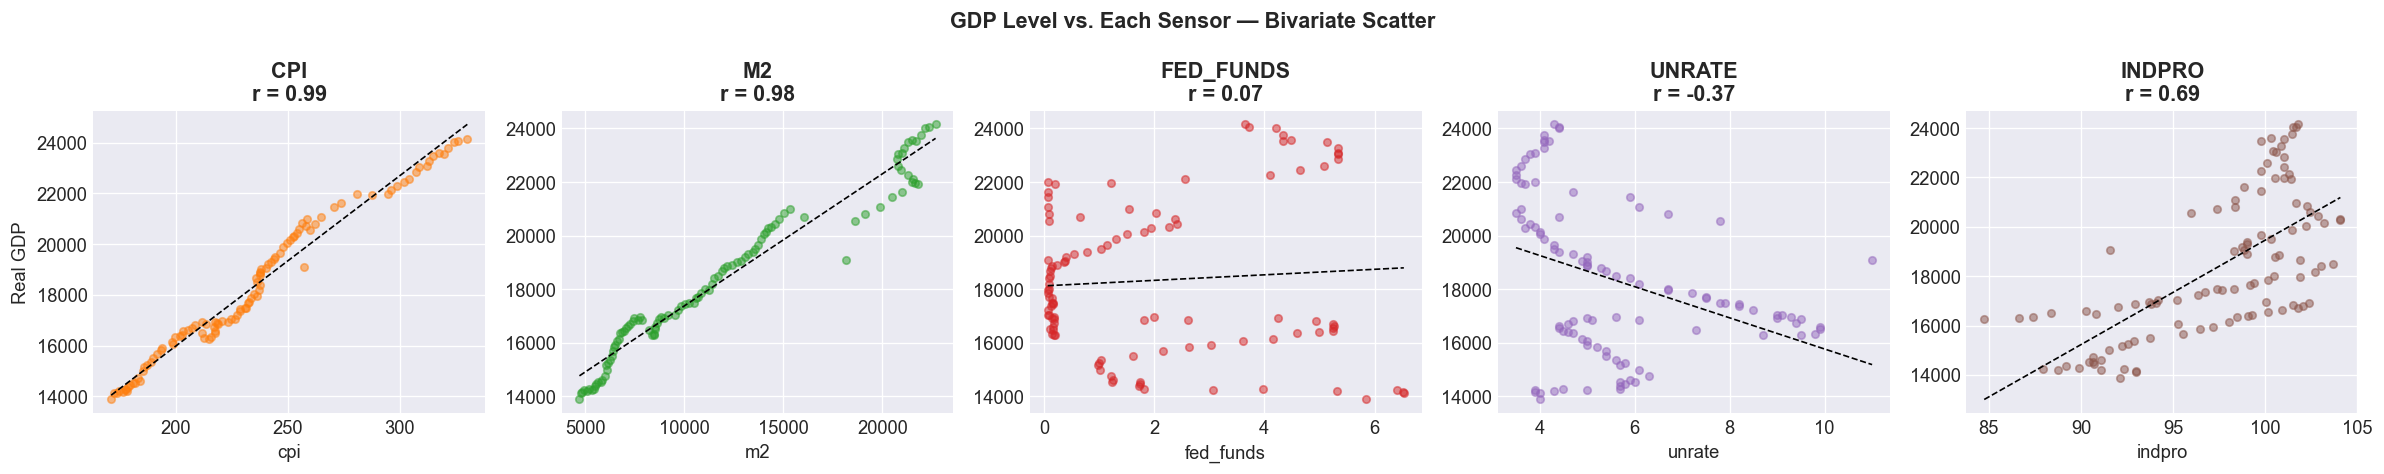

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, name in enumerate(monthly_series):
    ax = axes[i]
    ax.scatter(master[name], master['gdp'],
               alpha=0.5, s=20, color=f'C{i+1}')
    
    # Best-fit line
    z = np.polyfit(master[name].dropna(), master['gdp'].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(master[name].min(), master[name].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1)
    
    corr = master[[name, 'gdp']].corr().iloc[0, 1]
    ax.set_title(f'{name.upper()}\nr = {corr:.2f}', fontweight='bold')
    ax.set_xlabel(name)
    if i == 0:
        ax.set_ylabel('Real GDP')

plt.suptitle('GDP Level vs. Each Sensor — Bivariate Scatter',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Key EDA Takeaways

| Finding | Implication for Modelling |
|---|---|
| GDP is **quarterly**; all sensors are **monthly** | Must resample/align before merging |
| **No missing values** in any series | No imputation needed for the raw data |
| COVID-19 Q2-2020 is a massive outlier (-8.9% QoQ) | May need a **recession dummy** feature in Phase 2 |
| M2, CPI, GDP are **highly correlated** in levels (~0.9+) | Work in **growth rates / differences**, not levels |
| Fed Funds Rate shows non-monotonic behaviour (low → high → low) | Useful as a **monetary policy regime indicator** |
| UNRATE is counter-cyclical (rises in recessions) | Good leading indicator with negative correlation to GDP growth |

### ✅ EDA Complete — Ready for Feature Engineering (Step 3)